# Figures Section 1
Here, the figures corresponding to the section on bulk data in the final report will be generated

## Imports

In [1]:
### Enabling autoreload ##
%load_ext autoreload
%autoreload 2

In [2]:
### Directories and Files ###
root = '../../'
data_dir_bulk = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/taghic' # Importing was not working with relative root+'..' approach, so replace with local data
scc_dir_bulk = f"{root}Generated Data/mouse_scc_chr1/mouse_chr1_scc.csv" # Generated in chr1_bulk_scc_mouse.ipynb
figure_save_dir = f"{root}Generated Data/Final Report/Section 1/Final Figures/"

In [3]:
### Imports ###
import sys
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(root+'Scripts')
from hicdatautils import import_cool_dir, fetch_region, hic_ot_optim, hic_ot_bulk_threshold_sequential, compare_metrics
from hicvisutils import hic_vis_region_zoom
from ot import dist, solve
from time import perf_counter
from itertools import combinations

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
### Importing coolers ###
clrs_bulk = import_cool_dir(data_dir_bulk, 1_000_000)

## Figure 1A
A visualization of chromosome 1 of a bulk contact map.

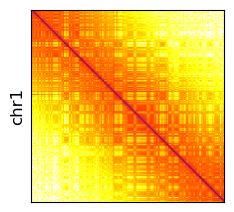

In [7]:
# Visualization
fig, ax = plt.subplots(figsize=(2.5, 2.5))
hic_vis_region_zoom(clrs_bulk[0], "1", cmap="higlass", chr_label="chr1", ax=ax)
plt.savefig(f"{figure_save_dir}/F1A.pdf")

## Figure 1B
Showing that OT cost increases with noise added.

In [44]:
### Setting parameters
sigma_list = [0, 0.25, 0.5, 0.75, 1.0]
seeds = [0, 1, 2, 3, 42]
g_chr1 = fetch_region(clrs_bulk[0], chrom="1")

In [50]:
### OT
    # Preparing base matrix
matrix_mask = np.triu(g_chr1, k=0) > 0
matrix_coords = np.column_stack(np.where(matrix_mask))
g_chr1_values = g_chr1[matrix_mask]
g_chr1_values_norm = g_chr1_values / g_chr1_values.sum()

    # Storing results
raw_costs = {}
mean_costs = []
std_costs = []

    # Compute cost per noise matrix
for sigma in sigma_list:
    print(f"Processing sigma={sigma}")
    sigma_costs = []

    for seed in seeds:
        rng = np.random.default_rng(seed=seed)

        # Generate noise
        noise = rng.lognormal(mean=0, sigma=sigma, size=g_chr1.shape)
        noise_map = g_chr1 * noise

        # Extracting info
        noise_mask = np.triu(noise_map, k=0) > 0
        noise_coords = np.column_stack(np.where(noise_mask))
        noise_values = noise_map[noise_mask]
        noise_values_norm = noise_values / noise_values.sum()
    
        # Forming cost matrix
        M = dist(matrix_coords, noise_coords)

        # OT cost
        cost = solve(M, g_chr1_values_norm, noise_values_norm).value
        sigma_costs.append(cost)
    
    # Saving
    raw_costs[sigma] = sigma_costs
    mean_costs.append(np.mean(sigma_costs))
    std_costs.append(np.std(sigma_costs))

Processing sigma=0
Processing sigma=0.25


/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/ot/lp/_network_simplex.py:520: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


Processing sigma=0.5
Processing sigma=0.75
Processing sigma=1.0


In [ ]:
### Saving Data ###
save_dir_1b = f"{root}Generated Data/Final Report/Figure 1/Panel B/artificial_noise_ot.csv"
costs_df = pd.DataFrame.from_dict(raw_costs, orient='index', columns=seeds)
costs_df.to_csv(save_dir_1b)

In [50]:
costs_df

,0,1,2,3,42
0.00,0.000000,0.000000,0.000000,0.000000,0.000000
0.25,4.795955,0.837069,2.002510,0.759815,4.350894
0.50,16.665096,2.548371,7.312342,2.301254,18.835673
0.75,35.605149,10.386811,30.505530,20.059251,67.968536
1.00,120.334647,88.470620,160.793967,125.863179,109.790629


In [53]:
### Loading Data ###
save_dir_1b = f"{root}Generated Data/Final Report/Figure 1/Panel B/artificial_noise_ot.csv"
costs_df = pd.read_csv(save_dir_1b, index_col=0)
std_costs = costs_df.std(axis=1)

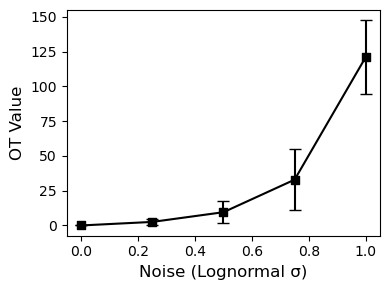

In [ ]:
### Figure
figb, ax = plt.subplots(figsize=(4,3))
ax.scatter(sigma_list, costs_df.mean(axis=1), marker='s', c='black', label='Mean value')
ax.errorbar(
    sigma_list,
    costs_df.mean(axis=1),
    yerr=std_costs,
    label='Standard deviation',
    barsabove=True,
    capsize=4,
    c="black"
)
ax.set_xlabel("Noise (Lognormal σ)", size='12')
ax.set_ylabel("OT Value", size='12')
plt.tight_layout()
plt.savefig(f"{figure_save_dir}/F1B.pdf")

## Figure 1C+D
Correpondence with SCC. Uses res=2, thres=25% as this is the best resolution and threshold that runs for UOT.

In [10]:
### Setting directories
save_dir_ot = f"{root}Generated Data/Final Report/Figure 1/Panel C/OT/"
save_dir_uot = f"{root}Generated Data/Final Report/Figure 1/Panel C/UOT/"
save_dir_scc = f"{root}Generated Data/Final Report/Figure 1/Panel C/SCC/"

In [8]:
### Generating OT Data
results = hic_ot_optim(
    coolers=clrs_bulk,
    chrom="1",
    selection="threshold",
    norm="sum",
    thres=25,
    thres_type="percentile",
    rebin_factor=2
)

results.to_csv(f"{save_dir_ot}balanced_BULKf1c_ot_res=2_thres=25.csv")

 36%|███▌      | 16/45 [00:08<00:15,  1.92it/s]/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 45/45 [00:21<00:00,  2.05it/s]


In [7]:
### Generating UOT data
results = hic_ot_bulk_threshold_sequential(
    coolers=clrs_bulk, 
    chrom="1",
    norm="max",
    thres=25,
    thres_type="percentile",
    rebin_factor=2,
    unbalanced=0.1)

results.to_csv(f"{save_dir_uot}balanced_BULKf1c_uot_res=2_thres=25_regm=0.1.csv")

100%|██████████| 45/45 [54:58<00:00, 73.30s/it]


In [11]:
### Loading Data
    # SCC
chr1_scc_bulk = pd.read_csv(scc_dir_bulk, index_col=0)

    # Balanced OT
chr1_bulk_ot = pd.read_csv(f"{save_dir_ot}balanced_BULKf1c_ot_res=2_thres=25.csv", index_col=0)

    # UOT
chr1_bulk_uot = pd.read_csv(f"{save_dir_uot}balanced_BULKf1c_uot_res=2_thres=25_regm=0.1.csv", index_col=0)

### Panel C
SCC and balanced OT

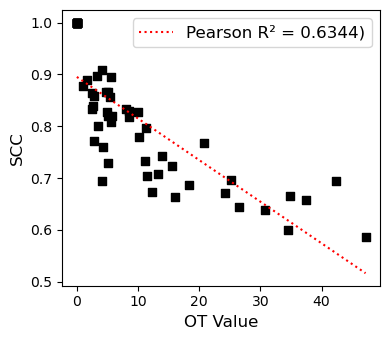

In [14]:
fig1c, ax = plt.subplots(figsize=(4,3.5))
compare_metrics(
    chr1_bulk_ot, 
    chr1_scc_bulk,
    "OT Value",
    "SCC",
    ax=ax)
plt.savefig(f"{figure_save_dir}F1C.pdf")

### Panel D
SCC and UOT

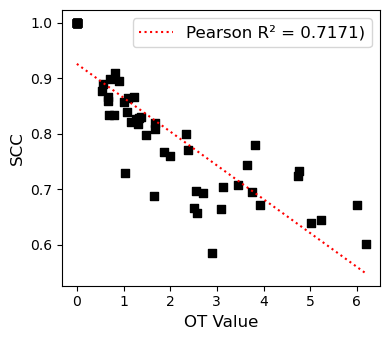

In [15]:
fig1c, ax = plt.subplots(figsize=(4,3.5))
compare_metrics(
    chr1_bulk_uot, 
    chr1_scc_bulk,
    "OT Value",
    "SCC",
    ax=ax)
plt.savefig(f"{figure_save_dir}F1D.pdf")

## Figure 1E+F
Clustermaps for bulk costs

In [8]:
### Making labels more interpretable
    # Extracting short labels
bulk_labels = chr1_bulk_ot.columns
bulk_labels_mapper = {}
for label in bulk_labels:
    trimmed_label = label.split("_")[1]
    if trimmed_label == "G":
        trimmed_label = "GR"
    bulk_labels_mapper[label] = trimmed_label

    # Renaming indices and columns
chr1_bulk_ot = chr1_bulk_ot.rename(columns=bulk_labels_mapper, index=bulk_labels_mapper)
chr1_bulk_uot = chr1_bulk_uot.rename(columns=bulk_labels_mapper, index=bulk_labels_mapper)

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


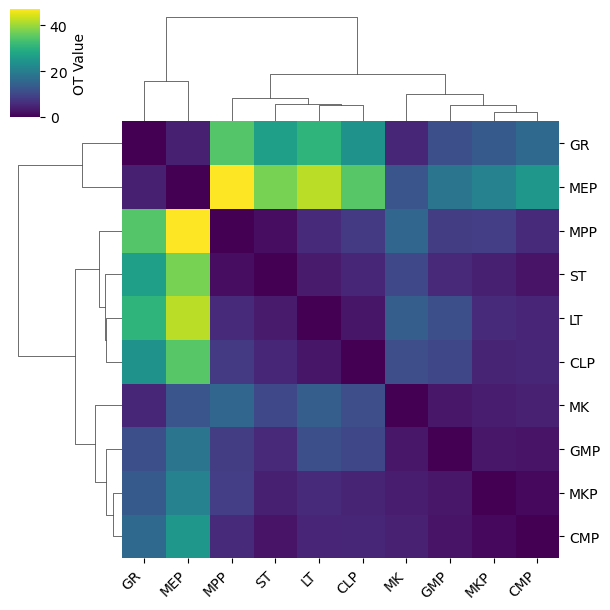

In [18]:
### Balanced
g = sns.clustermap(
    chr1_bulk_ot, 
    cmap="viridis",
    vmin=0,
    cbar_kws={'label' : 'OT Value'},
    figsize=(6,6)
)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.show()

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


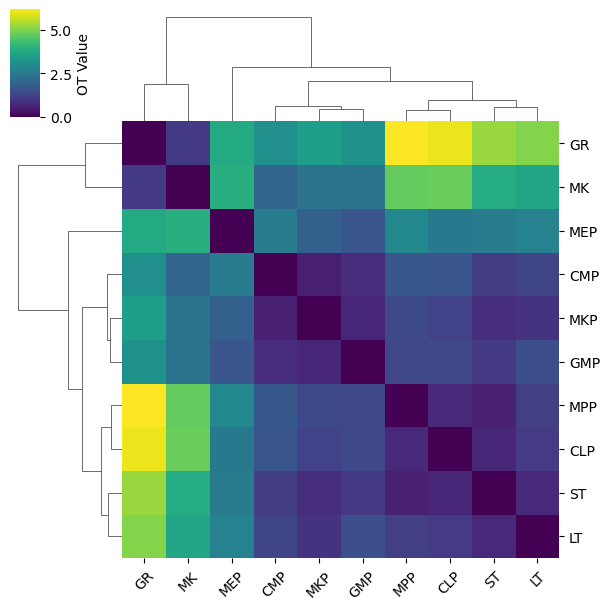

In [32]:
### Unbalanced
g = sns.clustermap(
    chr1_bulk_uot, 
    cmap="viridis",
    vmin=0,
    cbar_kws={'label' : 'OT Value'},
    figsize=(6,6)
)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45)
plt.show()

In [ ]:
fig = plt.figure(figsize=(7.5, 4))


<Figure size 750x400 with 0 Axes>

## Supplemental Figure 1
Shows correspondence for multiple thresholds and resolutions

### Generating and Loading Data

In [8]:
subset_s1a = clrs_bulk[0:5]
binning_factors = [8, 4, 2, 1]
thresholds = [90, 75, 50, 25, 0]
save_dir = f"{root}Generated Data/Final Report/Figure S1/OT/"
time_path = f"{save_dir}s1a_ot_balanced_times.csv"

In [ ]:
### Generating Comparisons OT
for factor in binning_factors:
    for thres in thresholds:
        print(f"OT FOR RES={factor}, THRES={thres}")
        if not os.path.exists(f"{save_dir}balanced_BULK_S1A_res={factor}_thres={thres}.csv"):
            time = perf_counter()

            # OT
            results = hic_ot_bulk_threshold_sequential(
                subset_s1a, 
                "1",
                norm="sum",
                thres=thres,
                thres_type="percentile",
                rebin_factor=factor)

            # Updating time file
            time = perf_counter() - time

                # Cast to strings to ensure proper indexing
            res_str = str(factor)
            thres_str = str(thres)

                # Make or import csv
            if os.path.exists(time_path):
                df_calc = pd.read_csv(time_path, index_col=0)
                df_calc.index = df_calc.index.astype(str)
            else:
                df_calc = pd.DataFrame()

                # Insert value in row
            df_calc.at[thres_str, res_str] = time

                # Save to CSV
            df_calc.to_csv(time_path)
            
            results.to_csv(f"{save_dir}balanced_BULK_S1A_res={factor}_thres={thres}.csv")

OT FOR RES=8, THRES=90
OT FOR RES=8, THRES=75
OT FOR RES=8, THRES=50
OT FOR RES=8, THRES=25
OT FOR RES=8, THRES=0
OT FOR RES=4, THRES=90
OT FOR RES=4, THRES=75
OT FOR RES=4, THRES=50
OT FOR RES=4, THRES=25
OT FOR RES=4, THRES=0
OT FOR RES=2, THRES=90
OT FOR RES=2, THRES=75
OT FOR RES=2, THRES=50
OT FOR RES=2, THRES=25
OT FOR RES=2, THRES=0
OT FOR RES=1, THRES=90
OT FOR RES=1, THRES=75
OT FOR RES=1, THRES=50
OT FOR RES=1, THRES=25
OT FOR RES=1, THRES=0


In [7]:
### Generating comparisons UOT ###
time_path = f"{save_dir}s1a_ot_unbalanced_reg_m=0.1_times.csv"
for factor in binning_factors:
    for thres in thresholds:
        print(f"UOT FOR RES={factor}, THRES={thres}")
        if not os.path.exists(f"{save_dir}unbalanced_BULK_S1C_res={factor}_thres={thres}_reg_m=0.1.csv"):
            time = perf_counter()

            # OT
            results = hic_ot_bulk_threshold_sequential(
                subset_s1a, 
                "1",
                norm="max",
                thres=thres,
                thres_type="percentile",
                rebin_factor=factor,
                unbalanced=0.1)

            # Updating time file
            time = perf_counter() - time

                # Cast to strings to ensure proper indexing
            res_str = str(factor)
            thres_str = str(thres)

                # Make or import csv
            if os.path.exists(time_path):
                df_calc = pd.read_csv(time_path, index_col=0)
                df_calc.index = df_calc.index.astype(str)
            else:
                df_calc = pd.DataFrame()

                # Insert value in row
            df_calc.at[thres_str, res_str] = time

                # Save to CSV
            df_calc.to_csv(time_path)
            
            results.to_csv(f"{save_dir}unbalanced_BULK_S1C_res={factor}_thres={thres}_reg_m=0.1.csv")

UOT FOR RES=8, THRES=90


100%|██████████| 10/10 [00:00<00:00, 10.18it/s]


UOT FOR RES=8, THRES=75
UOT FOR RES=8, THRES=50
UOT FOR RES=8, THRES=25
UOT FOR RES=8, THRES=0
UOT FOR RES=4, THRES=90


100%|██████████| 10/10 [00:01<00:00,  6.98it/s]


UOT FOR RES=4, THRES=75
UOT FOR RES=4, THRES=50
UOT FOR RES=4, THRES=25
UOT FOR RES=4, THRES=0
UOT FOR RES=2, THRES=90


...

UOT FOR RES=2, THRES=75
UOT FOR RES=2, THRES=50
UOT FOR RES=2, THRES=25
UOT FOR RES=2, THRES=0
UOT FOR RES=1, THRES=90


100%|██████████| 10/10 [03:02<00:00, 18.30s/it]


UOT FOR RES=1, THRES=75


  0%|          | 0/10 [00:00<?, ?it/s]

: 

In [5]:
### Helper function for importing data ###
def import_data_sup1(balanced: bool=True) -> dict[str, pd.DataFrame]:
    '''
        Imports OT data (balanced or unbalanced) for supplementary
        figure 1 as a dictionary with resolution and threshold as the key.

        Parameters
        ----------
        balanced : bool
            Determines whether data to be imported is balanced.
            Default = True.
        
        Returns
        -------
        data_df : dict
            Dictionary containing all dataframes with keys as
            "[res] Mb, τ=[thres]".
    '''
    # Setting patterns
    if balanced:
        pattern = os.path.join(save_dir, "balanced_BULK_S1A_res=*_thres=*.csv")
        regex = r"balanced_BULK_S1A_res=(?P<res>[^_]+)_thres=(?P<thres>[^.]+)\.csv"
    else:
        pattern = os.path.join(save_dir, "unbalanced_BULK_S1C_res=*_thres=*_reg_m=0.1.csv")
        regex = r"unbalanced_BULK_S1C_res=(?P<res>[^_]+)_thres=(?P<thres>[^_]+)_reg_m=0\.1\.csv"
    
    # Importing
    data_dict = {}
    for filepath in glob.glob(pattern):
        filename = os.path.basename(filepath)
        match = re.search(regex, filename)

        if match:
            res = match.group("res")
            thres = match.group("thres")
            key = f"{res} Mb, τ={thres}%"
            data_dict[key] = pd.read_csv(filepath, index_col=0)
        else:
            print(f"Warning: Could not parse filename: {filename}")

    return data_dict

In [6]:
### Helper function for correspondences ###
def correspondence_matrix(results: dict[str, pd.DataFrame]) -> pd.DataFrame:
    '''
        Takes OT results in a dict given with resolution
        and threshold as keys and returns a dataframe
        giving linear correspondence between all methods.

        Parameters
        ----------
        results : dict[str, pd.DataFrame]
            Results imported as a dict by import_data_sup1.
            
        Returns
        -------
        cor_mat : pd.DataFrame
            Symmetric dataframe giving Pearson r2 between upper
            triangles
    '''
    keys = list(results.keys())
    n    = len(keys)

    # Extract upper triangles
    triags = {}
    for key, df in results.items():
        matrix = df.values
        idx = np.triu_indices(matrix.shape[0], k=1)  # k=1 excludes the diagonal
        triags[key] = matrix[idx].astype(float)
    
    # Correspondence matrix
    cor_mat = pd.DataFrame(np.ones((n, n)), index=keys, columns=keys)

    for key_a, key_b in combinations(keys, 2):
        vec_a = triags[key_a]
        vec_b = triags[key_b]

        r = np.corrcoef(vec_a, vec_b)[0, 1]
        r_squared = r ** 2

        cor_mat.loc[key_a, key_b] = r_squared
        cor_mat.loc[key_b, key_a] = r_squared 
    
    return cor_mat

### Panel A + B
Times

In [23]:
### Getting number of comparisons to convert to time per comparison
results_shape = import_data_sup1()["1 Mb, τ=0%"].shape[0]
n_comparisons = (results_shape ** 2 - results_shape) / 2

10.0

(np.float64(0.07860851245117688), 1000.0)

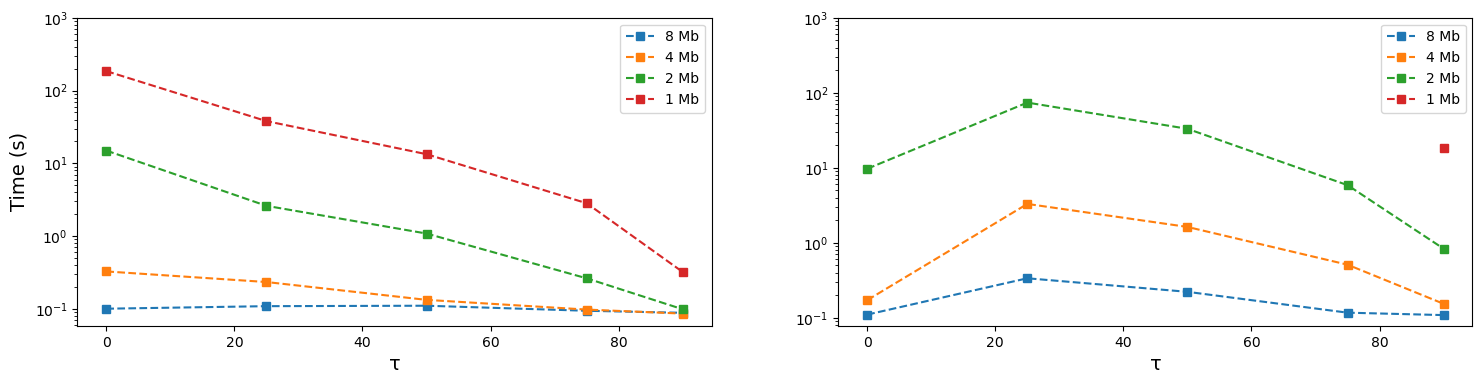

In [24]:
# Importing times
time_path = f"{save_dir}s1a_ot_balanced_times.csv"
time_path_unbalanced = f"{save_dir}s1a_ot_unbalanced_reg_m=0.1_times.csv"
times_s1balanced = pd.read_csv(time_path, index_col=0).sort_index(ascending=True)
times_s1unbalanced = pd.read_csv(time_path_unbalanced, index_col=0).sort_index(ascending=True)
res_list = ["8", "4", "2", "1"]
labels = [
    "8 Mb",
    "4 Mb",
    "2 Mb",
    "1 Mb"
]

# Initialize Figure
fig, ax = plt.subplots(1, 2, figsize=(18, 4))

# Figure Balanced
for res in res_list:
    ax[0].plot(times_s1balanced[res].index, times_s1balanced[res]/n_comparisons, linestyle='--', marker='s')
ax[0].set_yscale('log')
ax[0].legend(labels=labels)
ax[0].set_xlabel("τ", size=14)
ax[0].set_ylabel("Time (s)", size=14)
ax[0].set_ylim(top=1e3)

# Figure Unbalanced
for res in res_list:
    ax[1].plot(times_s1unbalanced[res].index, times_s1unbalanced[res]/n_comparisons, linestyle='--', marker='s')
ax[1].set_yscale('log')
ax[1].set_xlabel("τ", size=14)
ax[1].legend(labels=labels)
ax[1].set_ylim(top=1e3)

### Panel C
Clustermaps correspondence

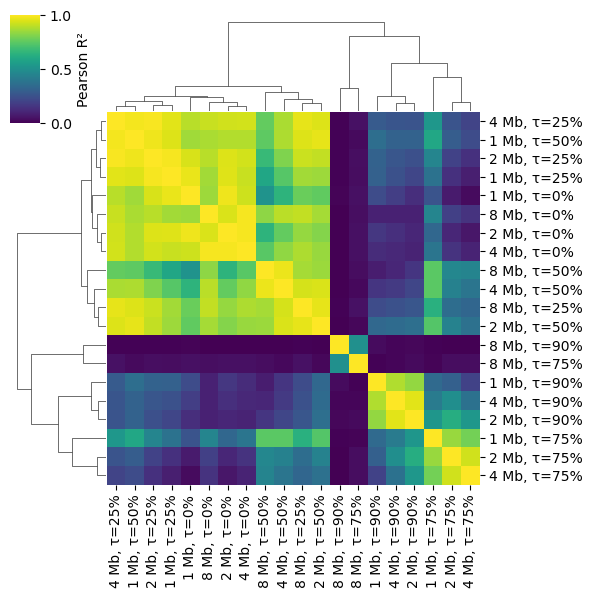

In [40]:
# Balanced
results_balanced = import_data_sup1()
cor_mat_balanced = correspondence_matrix(results_balanced)
g = sns.clustermap(
    cor_mat_balanced,
    cmap="viridis", 
    vmin=0,
    cbar_kws={'label' : 'Pearson R²'},
    figsize=(6,6)
)

plt.show()

### Panel D

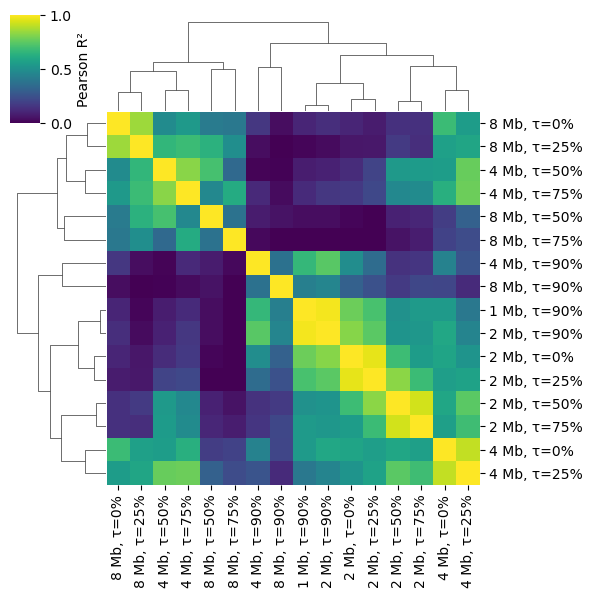

In [31]:
# Unbalanced
results_unbalanced = import_data_sup1(False)
cor_mat_unbalanced = correspondence_matrix(results_unbalanced)
sns.clustermap(
    cor_mat_unbalanced,
    cmap="viridis", 
    vmin=0,
    cbar_kws={'label' : 'Pearson R²'},
    figsize=(6,6)
)

## Supplementary Figure 2
Also compare OT and UOT.

np.float64(0.43572632612735857)

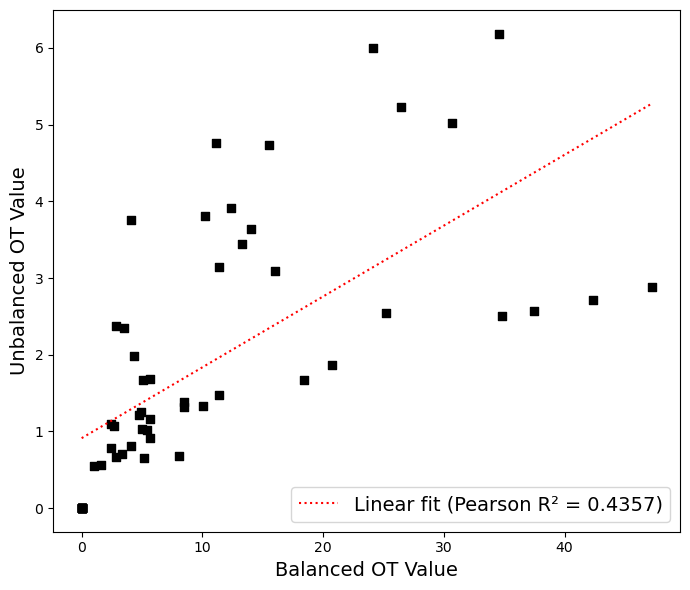

In [42]:
compare_metrics(
    chr1_bulk_ot,
    chr1_bulk_uot,
    "Balanced OT Value",
    "Unbalanced OT Value"
)